# Predicción del Sector Económico: Ensambles, SVM y Redes Neuronales

**Autor:** Arturo Vargas Espinosa

# Introducción, Planteamiento del Problema y Contexto

En el proyecto [LDA vs. árboles de decisión](../sector-economico-lda-arboles/README.md) se compararon dos modelos "sencillos" para predecir el **sector de actividad económica** (primario, secundario o terciario) en el que trabaja una persona ocupada en México, usando la Encuesta Nacional de Ocupación y Empleo (ENOE) del primer trimestre de 2026 del INEGI. El resultado fue que el árbol de decisión podado (F1-score macro de 0.542) le ganó a LDA (0.434), principalmente porque el árbol pudo usar variables categóricas (tipo de localidad y sexo) que LDA no podía usar.

Los tres sectores que se quieren predecir son (variable `rama_est1` de la ENOE):

- **Sector primario:** actividades que obtienen recursos directamente de la naturaleza, como la agricultura, la ganadería, el aprovechamiento forestal, la pesca y la caza. Es el trabajo "del campo" y se concentra sobre todo en zonas rurales.
- **Sector secundario:** actividades que transforman materias primas en productos, como la industria manufacturera (fábricas), la construcción, la minería (industria extractiva) y la generación de electricidad, gas y agua. Es el trabajo "de la industria".
- **Sector terciario:** actividades que no producen bienes sino que ofrecen servicios, como el comercio, el transporte, la educación, la salud, los restaurantes, los servicios financieros y el gobierno. Es el sector que más gente emplea en México (cerca de dos terceras partes de las personas ocupadas).

En este reporte se sigue con **exactamente el mismo problema, las mismas variables y la misma partición de entrenamiento/prueba**, pero ahora se prueban modelos más flexibles y potentes:

- **Random Forest** (método de ensamble basado en *bagging* de árboles)
- **Gradient Boosting** (método de ensamble basado en *boosting* de árboles)
- **Support Vector Machine** (clasificador de margen máximo con kernel)
- **Una red neuronal sencilla** construida desde cero con Keras

¿Por qué es relevante el problema? Saber qué perfil de persona trabaja en cada sector ayuda a entender la estructura del mercado laboral en México: por ejemplo, qué tan ligado está el trabajo en el campo a vivir en zonas rurales, o qué tanto se parecen (en ingreso y escolaridad) los trabajadores de la industria y de los servicios. Un modelo que logre distinguir bien los 3 sectores con pocas variables sociodemográficas nos dice que esas variables realmente capturan diferencias estructurales entre los sectores.

La pregunta que se quiere contestar en este reporte es: **¿los modelos más complejos realmente predicen mejor el sector económico que los modelos sencillos como LDA y decision Tree? Y si sí, ¿la mejora vale la pena considerando que son más difíciles de interpretar, más lentos y con más riesgo de sobreajuste?** Con esto se busca encontrar y entender como cambia el desempeño y el comportamiento del modelo conforme aumenta la complejidad.

# Metodología

Todos los modelos se entrenan con el mismo set de entrenamiento y se evalúan **una sola vez** con el mismo set de prueba, con las mismas métricas. Además, todas las decisiones sobre hiperparámetros se toman usando **únicamente el set de entrenamiento** (error *out-of-bag*, validación cruzada o una parte de entrenamiento apartada como validación), para no "hacer trampa" eligiendo el modelo que mejor le va al set de prueba (lo que se conoce como *test set leakage*).

### Random Forest

Un árbol de decisión es muy interpretable pero es **volátil**: si cambiamos un poco los datos de entrenamiento, el árbol resultante puede cambiar mucho (tiene alta varianza). La idea de los métodos de ensamble es combinar muchos modelos para reducir esa varianza.

- **Bagging (bootstrap aggregation):** se generan muchas muestras *bootstrap* (muestras del mismo tamaño que el set de entrenamiento, pero tomadas **con reemplazo**), se entrena un árbol profundo en cada una, y la predicción final es la clase que más árboles votaron (mayoría).
- **Random Forest** agrega un truco extra: en cada separación de cada árbol solo se permite elegir entre un subconjunto aleatorio de $m$ variables (típicamente $m \approx \sqrt{p}$). Esto sirve porque si hay una variable muy fuerte (como vimos en decision tree/LDA con `ur01`), en bagging casi todos los árboles la usarían en el primer nodo y serían muy parecidos entre sí (predicciones correlacionadas); al obligar a los árboles a usar otras variables, se "descorrelacionan" y el promedio reduce más la varianza.
- **Error out-of-bag (OOB):** en promedio cada muestra bootstrap contiene aproximadamente dos terceras partes de las observaciones; el tercio restante (las observaciones *out-of-bag*) se puede usar para evaluar el modelo sin necesidad de un set de validación aparte. Aquí se usa el OOB para elegir el tamaño mínimo de hoja.

### Boosting

En boosting los árboles **no** se entrenan de forma independiente, sino **secuencial**: cada árbol nuevo se enfoca en corregir los errores de los árboles anteriores. Se usan árboles pequeños ("weak learners"), y cada uno aporta solo un poquito (controlado por el *learning rate*), así que el modelo aprende lentamente.

- En **AdaBoost** esto se logra dándole más peso a las observaciones mal clasificadas en la siguiente iteración.
- En **Gradient Boosting** (el que se usa aquí) cada árbol nuevo se ajusta al gradiente de la función de pérdida (los "residuales") del modelo acumulado hasta ese momento.

A diferencia de Random Forest, en boosting agregar demasiados árboles **sí** puede generar sobreajuste, por eso se usa *early stopping*: se aparta una parte del entrenamiento como validación y se deja de agregar árboles cuando la pérdida en validación deja de mejorar.

### Support Vector Machine (SVM)

La idea base es el **clasificador de margen máximo**: de todos los hiperplanos que separan a dos clases, se elige el que queda más lejos de las observaciones (el que deja la "franja" más ancha entre las clases). Como en datos reales las clases casi nunca son perfectamente separables, se usa un **margen suave** (*support vector classifier*), que permite que algunas observaciones queden del lado incorrecto del margen o incluso del hiperplano. El parámetro $C$ controla qué tanto se castigan esas violaciones: un $C$ grande castiga mucho los errores (margen más estrecho, más riesgo de sobreajuste) y un $C$ chico los tolera más (margen más ancho, más sesgo).

Cuando la frontera entre clases no es lineal, la **SVM** usa un **kernel**, una función que mide la similitud entre observaciones y equivale a trabajar en un espacio de variables mucho más grande (incluso infinito, en el caso del kernel RBF o radial) sin tener que calcularlo explícitamente. La frontera final solo depende de los **vectores de soporte** (las observaciones que quedan sobre el margen o lo violan). Para más de 2 clases, `SVC` de sklearn usa el esquema *one-vs-one* (un clasificador por cada par de clases, y gana la clase con más votos).

La SVM es sensible a la escala de las variables (usa distancias), así que hay que estandarizar.

### Red neuronal

Una red neuronal *feedforward* está formada por capas de neuronas: una capa de entrada (las variables), una o más capas ocultas y una capa de salida. Cada neurona calcula una **suma ponderada** de sus entradas más un sesgo y le aplica una **función de activación** no lineal (aquí **ReLU** en las capas ocultas). Para clasificación multiclase la capa de salida tiene una neurona por clase con activación **softmax**, que convierte las salidas en probabilidades que suman 1.

Los pesos se aprenden con **gradiente descendente** (en este caso con el optimizador **Adam**), usando **backpropagation** para calcular cuánto contribuyó cada peso al error, y minimizando la pérdida *sparse categorical cross-entropy*. Para evitar sobreajuste se usa **early stopping** monitoreando la pérdida en un conjunto de validación (apartado del entrenamiento).

### Métricas de evaluación

Como las clases están muy desbalanceadas (el sector terciario tiene casi dos terceras partes de las observaciones), la **exactitud** por sí sola es engañosa: un modelo que siempre prediga "terciario" tendría 65.6% de exactitud sin haber aprendido nada. Por eso la métrica principal para comparar es el **F1-score macro** (promedio simple del F1 de las 3 clases, sin ponderar por su tamaño), acompañada de la exactitud, la precisión y la sensibilidad macro, la sensibilidad por clase y la matriz de confusión. Además, para revisar **sobreajuste** se compara el F1 macro en entrenamiento contra prueba, y para revisar **estabilidad** se usa validación cruzada de 5 folds.

# Resumen de dataset

Se trabaja con el mismo archivo que en los demás proyectos con la ENOE: `enoe_2026_1t_limpio.csv`, que contiene los microdatos de la ENOE del primer trimestre de 2026 (INEGI). Cada fila es una persona empleada encuestada.

In [1]:
import os
import time
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
warnings.filterwarnings('ignore')

ruta = 'Datos/enoe_2026_1t_limpio.csv'

df = pd.read_csv(ruta, low_memory=False)
print(df.shape)
df.head()

(126226, 30)


,r_def,cve_ent,con,upm,n_pro_viv,v_sel,n_hog,h_mud,n_ren,c_res,...,tue1,pre_asa,niv_ins,anios_esc,hrsocup,ingocup,imssissste,emp_ppal,p6c,p6d
0,0,9,40006,906681,117,5,1,0,1,1,...,2,1,3,11,50,10000,1,2,,1
1,0,9,40018,912598,63,3,1,0,5,1,...,3,2,4,12,30,12900,4,1,,6
2,0,9,40018,912598,81,4,1,0,3,1,...,2,1,4,15,40,10000,2,2,,3
3,0,9,40039,922769,109,5,1,0,2,1,...,3,0,4,12,40,12900,4,1,,6
4,0,9,40040,911404,7,2,1,0,1,1,...,1,2,2,9,15,9000,4,1,,6


El archivo tiene 126,226 observaciones y 30 columnas (la descripción completa de todas las columnas está en el proyecto de [clasificación de prestaciones laborales](../clasificacion-prestaciones-enoe/README.md)). Para este reporte solo se usan las siguientes variables:

| Variable | Descripción | Tipo | Uso |
|---|---|---|---|
| `rama_est1` | Sector de actividad económica (1 = primario, 2 = secundario, 3 = terciario) | Categórica | **Variable de salida** |
| `eda` | Edad en años | Numérica | Explicativa |
| `anios_esc` | Años de escolaridad | Numérica | Explicativa |
| `hrsocup` | Horas trabajadas a la semana | Numérica | Explicativa |
| `ingocup` | Ingreso mensual (pesos) | Numérica | Explicativa (en modelos de árboles) |
| `log_ingocup` | Logaritmo natural de `ingocup` | Numérica | Explicativa (en modelos sensibles a la escala) |
| `sex01` | Sexo (0 = hombre, 1 = mujer), recodificada de `sex` | Binaria | Explicativa |
| `ur01` | Tipo de localidad (0 = urbana, 1 = rural), recodificada de `ur` | Binaria | Explicativa |

# Preparación del escenario experimental

## Limpieza

Se aplican exactamente los mismos pasos de limpieza que en el proyecto [LDA vs. árboles de decisión](../sector-economico-lda-arboles/README.md), para llegar a los mismos datos:

- Se quitan las observaciones con `rama_est1 = 4` (sector no especificado).
- Se quitan los identificadores de la encuesta y las columnas `p6c` y `n_hij` (vacías o con fuga de datos).
- Se quitan observaciones con escolaridad no especificada (`anios_esc = 99`) y con horas trabajadas poco realistas (0 o más de 119).
- Se recodifican `sex` y `ur` a 0/1 y se calcula el logaritmo del ingreso.

In [2]:
sub = df[df['rama_est1'].isin([1, 2, 3])].copy()          # se quita el codigo 4 (no especificado)
sector_map = {1: 'Primario', 2: 'Secundario', 3: 'Terciario'}
sub['Sector'] = sub['rama_est1'].map(sector_map)

ids = ['r_def', 'c_res', 'cve_ent', 'con', 'upm', 'n_pro_viv',
       'v_sel', 'n_hog', 'h_mud', 'n_ren']
sub = sub.drop(columns=ids + ['p6c', 'n_hij'])

sub = sub[sub['anios_esc'] != 99]                             # anios_esc no especificado
sub = sub[(sub['hrsocup'] <= 119) & (sub['hrsocup'] != 0)]    # horas trabajadas poco realistas

sub['sex01'] = sub['sex'].replace({1: 0, 2: 1})   # 0 = hombre, 1 = mujer
sub['ur01'] = sub['ur'].replace({1: 0, 2: 1})     # 0 = urbano, 1 = rural
sub['log_ingocup'] = np.log(sub['ingocup'])       # log de ingreso (para modelos sensibles a la escala)

print("Shape final tras limpieza:", sub.shape)
print(sub['Sector'].value_counts())

Shape final tras limpieza: (120430, 22)
Sector
Terciario     79025
Secundario    32355
Primario       9050
Name: count, dtype: int64


Se llega a las mismas **120,430 observaciones** (79,025 terciario, 32,355 secundario y 9,050 primario).

## ¿El dataset es adecuado para estos modelos?

Antes de entrenar hay que confirmar un par de cosas que estos modelos necesitan:

- **Sin valores faltantes ni infinitos:** ninguno de los 4 modelos (en su implementación de sklearn/Keras) acepta valores faltantes.
- **Escala de las variables:** la SVM y la red neuronal trabajan con distancias y gradientes, así que si una variable tiene una escala mucho más grande que las demás (como el ingreso, que llega a 250,000) va a dominar al modelo. Para estos modelos se usa el logaritmo del ingreso y se estandarizan todas las variables. Los modelos basados en árboles (Random Forest y Boosting) no se ven afectados por la escala, así que usan las variables tal cual.

In [3]:
vars_base = ['eda', 'anios_esc', 'hrsocup', 'ingocup', 'log_ingocup', 'sex01', 'ur01']

print("Valores faltantes por variable:")
print(sub[vars_base + ['rama_est1']].isna().sum())
print("\nValores infinitos en log_ingocup:", np.isinf(sub['log_ingocup']).sum())
print("Ingreso minimo:", sub['ingocup'].min())
print()
print(sub[vars_base].describe().T.round(2))

Valores faltantes por variable:
eda            0
anios_esc      0
hrsocup        0
ingocup        0
log_ingocup    0
sex01          0
ur01           0
rama_est1      0
dtype: int64

Valores infinitos en log_ingocup: 0
Ingreso minimo: 2

                count      mean      std    min      25%      50%       75%  \
eda          120430.0     40.24    14.21  12.00    29.00    39.00     51.00   
anios_esc    120430.0     10.66     4.16   0.00     9.00    11.00     12.00   
hrsocup      120430.0     41.45    16.61   1.00    32.00    45.00     48.00   
ingocup      120430.0  11181.50  8940.77   2.00  6450.00  9460.00  13000.00   
log_ingocup  120430.0      9.07     0.77   0.69     8.77     9.15      9.47   
sex01        120430.0      0.42     0.49   0.00     0.00     0.00      1.00   
ur01         120430.0      0.38     0.48   0.00     0.00     0.00      1.00   

                   max  
eda              98.00  
anios_esc        24.00  
hrsocup         119.00  
ingocup      250000.00  
log_i

No hay ningún valor faltante ni infinito (el ingreso mínimo es 2 pesos, así que el logaritmo siempre existe). También se ve lo que ya sabíamos: `ingocup` tiene una escala muchísimo más grande (promedio de 11,181 y máximo de 250,000) que las demás variables, y está muy sesgada a la derecha (el promedio es mucho mayor que la mediana), por eso para la SVM y la red se usa `log_ingocup`, que tiene un rango mucho más compacto (0.69 a 12.43). Con esto, el dataset está listo para los 4 modelos.

## Partición de entrenamiento y prueba

Para que la comparación con LDA y Decision Tree (y entre los modelos de este reporte) sea justa, se usa **exactamente la misma partición**: 80% entrenamiento y 20% prueba, estratificada por sector y con la misma semilla (`random_state=67`). Así, todos los modelos, tanto los de referencia como los nuevos, se evalúan sobre las mismas 24,086 personas.

In [4]:
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency

datos = sub[vars_base + ['rama_est1', 'Sector']].copy()

train, test = train_test_split(
    datos, train_size=0.8, random_state=67,
    stratify=datos['rama_est1']
)
print("Entrenamiento:", train.shape)
print("Prueba:       ", test.shape)

conteos_split = pd.DataFrame({
    'Entrenamiento': train['Sector'].value_counts().sort_index(),
    'Prueba': test['Sector'].value_counts().sort_index()
})
conteos_split['% Entrenamiento'] = (conteos_split['Entrenamiento'] / conteos_split['Entrenamiento'].sum() * 100).round(2)
conteos_split['% Prueba'] = (conteos_split['Prueba'] / conteos_split['Prueba'].sum() * 100).round(2)
print()
print(conteos_split)

chi2, p_valor, dof, esperado = chi2_contingency(conteos_split[['Entrenamiento', 'Prueba']].T)
print(f"\nchi2 = {chi2:.4f}   p-value = {p_valor:.4f}")

Entrenamiento: (96344, 9)
Prueba:        (24086, 9)

            Entrenamiento  Prueba  % Entrenamiento  % Prueba
Sector                                                      
Primario             7240    1810             7.51      7.51
Secundario          25884    6471            26.87     26.87
Terciario           63220   15805            65.62     65.62

chi2 = 0.0000   p-value = 1.0000


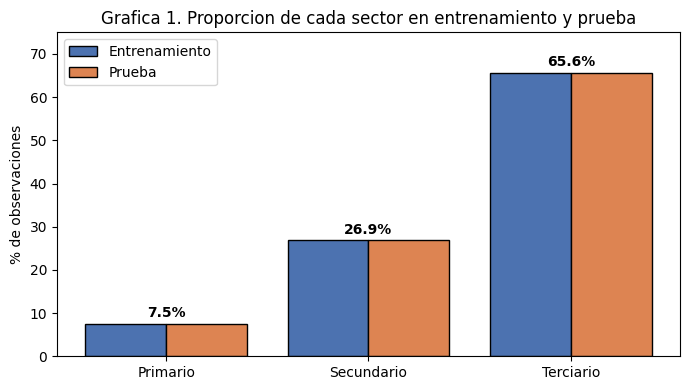

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(conteos_split))
ax.bar(x - 0.2, conteos_split['% Entrenamiento'], width=0.4, color='#4C72B0', edgecolor='black', label='Entrenamiento')
ax.bar(x + 0.2, conteos_split['% Prueba'], width=0.4, color='#DD8452', edgecolor='black', label='Prueba')
for i, v in enumerate(conteos_split['% Entrenamiento']):
    ax.text(i, v + 1.5, f"{v:.1f}%", ha='center', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(conteos_split.index)
ax.set_ylabel('% de observaciones')
ax.set_ylim(0, 75)
ax.set_title('Grafica 1. Proporcion de cada sector en entrenamiento y prueba')
ax.legend()
plt.tight_layout()
plt.show()

Las proporciones son idénticas en entrenamiento y prueba (7.51% primario, 26.87% secundario, 65.62% terciario), y la prueba ji-cuadrada da un p-value de 1.0, así que no hay ninguna evidencia de que la composición de clases dependa del subconjunto. Si más adelante un modelo tiene métricas distintas en entrenamiento y prueba, va a ser por cómo generaliza, no porque los subconjuntos sean distintos.


## Escalamiento y función de evaluación

Se preparan dos versiones de las variables explicativas:

- **Para árboles, Random Forest y Boosting:** las 6 variables originales (con `ingocup` sin transformar).
- **Para SVM, red neuronal (y regresión logística/LDA de referencia):** las 6 variables con `log_ingocup`, estandarizadas (media 0, desviación estándar 1). El `StandardScaler` se ajusta **solo con el set de entrenamiento** y después se aplica al de prueba, para que la información del set de prueba no se "filtre" al modelo.

Esto se hace porque la SVM y la red neuronal necesitan estos cambios, y para que la comparación entre modelos sea justa.

In [6]:
from sklearn.preprocessing import StandardScaler

clases = ['Primario', 'Secundario', 'Terciario']

# Variables "crudas" (para los modelos basados en arboles, no les afecta la escala)
vars_arbol = ['eda', 'anios_esc', 'hrsocup', 'ingocup', 'sex01', 'ur01']
# Variables para modelos sensibles a la escala (SVM, red neuronal, logistica, LDA)
vars_escala = ['eda', 'anios_esc', 'hrsocup', 'log_ingocup', 'sex01', 'ur01']

X_train_a, X_test_a = train[vars_arbol], test[vars_arbol]
y_train, y_test = train['rama_est1'], test['rama_est1']

# El escalador se ajusta SOLO con entrenamiento, y despues se aplica a prueba (evita fuga de informacion)
scaler = StandardScaler().fit(train[vars_escala])
X_train_s = pd.DataFrame(scaler.transform(train[vars_escala]), columns=vars_escala, index=train.index)
X_test_s = pd.DataFrame(scaler.transform(test[vars_escala]), columns=vars_escala, index=test.index)

print("Promedio (train, escalado):", X_train_s.mean().round(3).tolist())
print("Desv. est. (train, escalado):", X_train_s.std().round(3).tolist())

Promedio (train, escalado): [-0.0, -0.0, -0.0, -0.0, 0.0, 0.0]
Desv. est. (train, escalado): [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


Aquí podemos ver que el escalamiento funcionó bien. Todas las variables quedaron con **promedio 0** y **desviación estándar 1** en el set de entrenamiento.

- **Promedio 0:** cada variable queda centrada en 0. El `-0.0` es un número negativo muy muy chico que por el redondeo se ve así, pero es lo mismo que 0.
- **Desviación estándar 1:** ahora todas las variables tienen la misma escala. Antes el ingreso se media en miles de pesos y la escolaridad en años, entonces el ingreso hubiera "pesado" más solo por tener números más grandes. Esto es importante para la SVM y la red neuronal, que son sensibles a la escala.

El escalador se ajustó solo con los datos de entrenamiento y después se aplicó a los de prueba, para no usar información de prueba al preparar el modelo.

Para no repetir el mismo código en cada modelo, se define una función que calcula todas las métricas en el set de prueba, calcula también el F1 macro en entrenamiento (para revisar sobreajuste), guarda todo en una tabla y lo imprime. También se define una función para graficar la matriz de confusión, tanto en conteos como normalizada por fila (cada fila suma 1, así que la diagonal es la sensibilidad de cada clase).

In [7]:
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, classification_report, balanced_accuracy_score)

resultados = {}   # aqui se guardan las metricas de prueba de cada modelo
brecha = {}       # F1 macro en entrenamiento vs prueba (para revisar sobreajuste)

def evaluar(nombre, y_real, y_pred, y_real_train=None, y_pred_train=None, segundos=None):
    """Calcula las metricas en prueba, las guarda en `resultados` y las imprime."""
    resultados[nombre] = {
        'Exactitud': accuracy_score(y_real, y_pred),
        'Precision (macro)': precision_score(y_real, y_pred, average='macro'),
        'Sensibilidad (macro)': recall_score(y_real, y_pred, average='macro'),
        'F1-score (macro)': f1_score(y_real, y_pred, average='macro'),
        'Tiempo de entrenamiento (s)': segundos
    }
    if y_pred_train is not None:
        f1_tr = f1_score(y_real_train, y_pred_train, average='macro')
        f1_te = resultados[nombre]['F1-score (macro)']
        brecha[nombre] = {'F1 macro entrenamiento': f1_tr, 'F1 macro prueba': f1_te,
                          'Diferencia': f1_tr - f1_te}
    print(f"Exactitud: {resultados[nombre]['Exactitud']:.4f}")
    print(f"F1-score macro: {resultados[nombre]['F1-score (macro)']:.4f}")
    if y_pred_train is not None:
        print(f"F1-score macro en ENTRENAMIENTO: {brecha[nombre]['F1 macro entrenamiento']:.4f}")
    print()
    print(classification_report(y_real, y_pred, target_names=clases, digits=3))

def graficar_cm(y_real, y_pred, titulo):
    """Matriz de confusion en conteos y normalizada por fila (sensibilidad por clase)."""
    cm = confusion_matrix(y_real, y_pred)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False,
                xticklabels=clases, yticklabels=clases, ax=axes[0])
    axes[0].set_title('Conteos')
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', cbar=False,
                xticklabels=clases, yticklabels=clases, ax=axes[1])
    axes[1].set_title('Proporcion por fila (clase real)')
    for ax in axes:
        ax.set_xlabel('Clase predicha')
        ax.set_ylabel('Clase real')
    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()

### Modelos de referencia (regresión logística, LDA y árbol de decisión)

Para poder responder si los modelos de este reporte realmente mejoran, se necesita un punto de comparación. Se vuelven a entrenar, con la misma partición, los modelos del proyecto [LDA vs. árboles de decisión](../sector-economico-lda-arboles/README.md) y una regresión logística:

- **Regresión logística multinomial** (con `class_weight='balanced'`), como referencia de un modelo lineal sencillo.
- **LDA con priors uniformes**, el modelo final de LDA (solo con las 4 variables continuas).
- **Árbol de decisión podado**, el modelo final, con el mismo $\alpha$ óptimo que se encontró ahí por validación cruzada ($\alpha \approx 0.000416$) y `class_weight='balanced'`.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.tree import DecisionTreeClassifier as DTC

# 1) Regresion logistica multinomial (con pesos balanceados)
t0 = time.time()
logreg = LogisticRegression(class_weight='balanced', max_iter=1000).fit(X_train_s, y_train)
t_log = time.time() - t0
print("=== Regresion logistica ===")
evaluar('Regresion logistica', y_test, logreg.predict(X_test_s),
        y_train, logreg.predict(X_train_s), t_log)

# 2) LDA con priors uniformes
vars_lda = ['eda', 'anios_esc', 'hrsocup', 'log_ingocup']
t0 = time.time()
lda = LDA(priors=[1/3, 1/3, 1/3]).fit(X_train_s[vars_lda], y_train)
t_lda = time.time() - t0
print("=== LDA (priors uniformes) ===")
evaluar('LDA', y_test, lda.predict(X_test_s[vars_lda]),
        y_train, lda.predict(X_train_s[vars_lda]), t_lda)

# 3) Arbol de decision podado
t0 = time.time()
arbol = DTC(random_state=67, class_weight='balanced', ccp_alpha=0.00041576).fit(X_train_a, y_train)
t_arbol = time.time() - t0
print("=== Arbol de decision podado ===")
evaluar('Arbol de decision', y_test, arbol.predict(X_test_a),
        y_train, arbol.predict(X_train_a), t_arbol)

=== Regresion logistica ===
Exactitud: 0.5523
F1-score macro: 0.4879
F1-score macro en ENTRENAMIENTO: 0.4901

              precision    recall  f1-score   support

    Primario      0.261     0.839     0.398      1810
  Secundario      0.377     0.403     0.389      6471
   Terciario      0.808     0.581     0.676     15805

    accuracy                          0.552     24086
   macro avg      0.482     0.608     0.488     24086
weighted avg      0.651     0.552     0.578     24086

=== LDA (priors uniformes) ===
Exactitud: 0.4929
F1-score macro: 0.4340
F1-score macro en ENTRENAMIENTO: 0.4365

              precision    recall  f1-score   support

    Primario      0.178     0.577     0.272      1810
  Secundario      0.387     0.508     0.439      6471
   Terciario      0.777     0.477     0.591     15805

    accuracy                          0.493     24086
   macro avg      0.447     0.521     0.434     24086
weighted avg      0.627     0.493     0.526     24086

=== Arbol de de

LDA y el árbol dan exactamente los mismos resultados que en el proyecto de LDA y árboles de decisión (F1 macro de 0.434 y 0.542), lo que confirma que se está trabajando con los mismos datos y la misma partición. La regresión logística queda en medio (F1 macro de 0.488): al poder usar las variables binarias le gana a LDA, pero al seguir siendo un modelo lineal no alcanza al árbol. En los 3 modelos el F1 macro en entrenamiento y en prueba es prácticamente igual (diferencias menores a 0.004), es decir, **ninguno de estos modelos sencillos está sobreajustado**; su problema es más bien de sesgo (no tienen suficiente flexibilidad para capturar el patrón).

**La referencia a superar es el F1 macro de 0.542 del árbol podado.**

# Construcción de Modelos

## Random Forest
### Selección de hiperparámetros

Se usa `RandomForestClassifier` de `sklearn.ensemble` con los siguientes hiperparámetros:

- `n_estimators=300`: número de árboles. En Random Forest agregar más árboles no genera sobreajuste, solo estabiliza el resultado, 300 es suficiente para entrenarse bien sin tardarse tanto
- `max_features='sqrt'`: en cada separación se consideran $\sqrt{6} \approx 2$ variables al azar. Es el valor típico para clasificación y es justo lo que diferencia a Random Forest de bagging (bagging usaría las 6).
- `class_weight='balanced'`: se le da más peso a las clases minoritarias para que el modelo no se dedique a predecir solo "terciario".
- `min_samples_leaf`: el número mínimo de observaciones en cada hoja. Por default es 1 (los árboles crecen hasta que cada hoja es pura). Como tenemos mucho ruido (las clases se traslapan bastante), árboles tan profundos pueden memorizar el ruido; además, con `class_weight='balanced'` y hojas de 1 sola observación, el peso de las clases casi no tiene efecto. Este es el único hiperparámetro que se ajusta, y se elige usando el **F1 macro out-of-bag** (calculado solo con el set de entrenamiento).

In [9]:
from sklearn.ensemble import RandomForestClassifier as RFC

# Se prueba el tamano minimo de hoja usando el error OOB (solo datos de entrenamiento)
hojas = [1, 5, 10, 20, 50]
oob_rf = []
for msl in hojas:
    rf_tmp = RFC(n_estimators=200, max_features='sqrt', min_samples_leaf=msl,
                 class_weight='balanced', oob_score=True, n_jobs=-1, random_state=67)
    rf_tmp.fit(X_train_a, y_train)
    # Prediccion OOB de cada observacion = clase con mayor probabilidad promedio en los arboles donde quedo fuera
    pred_oob = rf_tmp.classes_[rf_tmp.oob_decision_function_.argmax(axis=1)]
    oob_rf.append({'min_samples_leaf': msl,
                   'OOB exactitud': rf_tmp.oob_score_,
                   'OOB F1 macro': f1_score(y_train, pred_oob, average='macro')})

oob_rf = pd.DataFrame(oob_rf)
print(oob_rf.round(4).to_string(index=False))
msl_opt = int(oob_rf.loc[oob_rf['OOB F1 macro'].idxmax(), 'min_samples_leaf'])
print("\nmin_samples_leaf seleccionado:", msl_opt)

 min_samples_leaf  OOB exactitud  OOB F1 macro
                1         0.6864        0.5711
                5         0.6736        0.5960
               10         0.6603        0.5876
               20         0.6468        0.5771
               50         0.6327        0.5644

min_samples_leaf seleccionado: 5


Se grafica el resultado para elegir el tamaño mínimo de hoja.

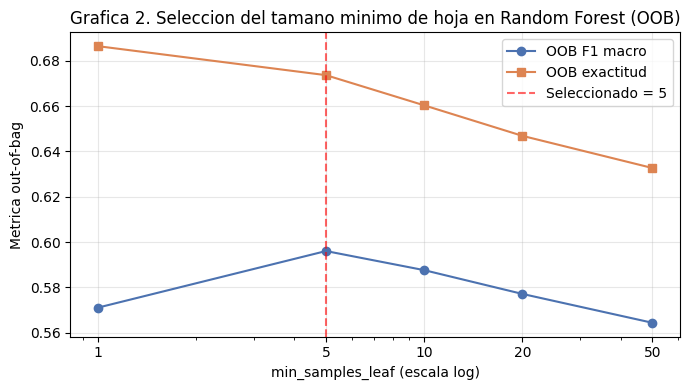

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(oob_rf['min_samples_leaf'], oob_rf['OOB F1 macro'], marker='o', color='#4C72B0', label='OOB F1 macro')
ax.plot(oob_rf['min_samples_leaf'], oob_rf['OOB exactitud'], marker='s', color='#DD8452', label='OOB exactitud')
ax.axvline(msl_opt, color='red', linestyle='--', alpha=0.6, label=f'Seleccionado = {msl_opt}')
ax.set_xscale('log')
ax.set_xticks(hojas)
ax.set_xticklabels(hojas)
ax.set_xlabel('min_samples_leaf (escala log)')
ax.set_ylabel('Metrica out-of-bag')
ax.set_title('Grafica 2. Seleccion del tamano minimo de hoja en Random Forest (OOB)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Aqui podemos ver la metrica out of bag empieza muy alto y bajando acorde que hay más hojas, pero en 5 sube el F1 macro, entonces vamos a escoger:

min_samples_leaf=5

### Entrenamiento y evaluación

In [11]:
t0 = time.time()
rf = RFC(n_estimators=300, max_features='sqrt', min_samples_leaf=msl_opt,
         class_weight='balanced', oob_score=True, n_jobs=-1, random_state=67)
rf.fit(X_train_a, y_train)
t_rf = time.time() - t0

pred_rf = rf.predict(X_test_a)
print(f"OOB exactitud: {rf.oob_score_:.4f}")
evaluar('Random Forest', y_test, pred_rf, y_train, rf.predict(X_train_a), t_rf)

OOB exactitud: 0.6743
Exactitud: 0.6726
F1-score macro: 0.5935
F1-score macro en ENTRENAMIENTO: 0.7195

              precision    recall  f1-score   support

    Primario      0.392     0.698     0.502      1810
  Secundario      0.500     0.508     0.504      6471
   Terciario      0.815     0.737     0.774     15805

    accuracy                          0.673     24086
   macro avg      0.569     0.648     0.593     24086
weighted avg      0.699     0.673     0.681     24086



- El Random Forest obtiene un **F1 macro de 0.594** y una **exactitud de 67.3%** en el set de prueba, contra 0.542 y 59.3% del árbol podado. Es una mejora clara: +0.051 en F1 macro y +7.9 puntos en exactitud.
- El **OOB** (0.674 de exactitud) prácticamente coincide con la exactitud en prueba (0.673), lo que confirma que el error OOB es una buena estimación del desempeño en datos nuevos.
- Por clase, la sensibilidad queda en 69.8% para primario, 50.8% para secundario y 73.7% para terciario. Comparado con el árbol (78% / 54% / 60%), el Random Forest detecta un poco menos a primario y secundario pero mucho mejor a terciario, y con **mejor precisión** en las clases minoritarias (primario pasa de 0.34 a 0.39 y secundario de 0.41 a 0.50). Es decir, se equivoca menos cuando dice que alguien es de primario o secundario.
- En entrenamiento el F1 macro es 0.720, bastante más alto que en prueba (0.594).

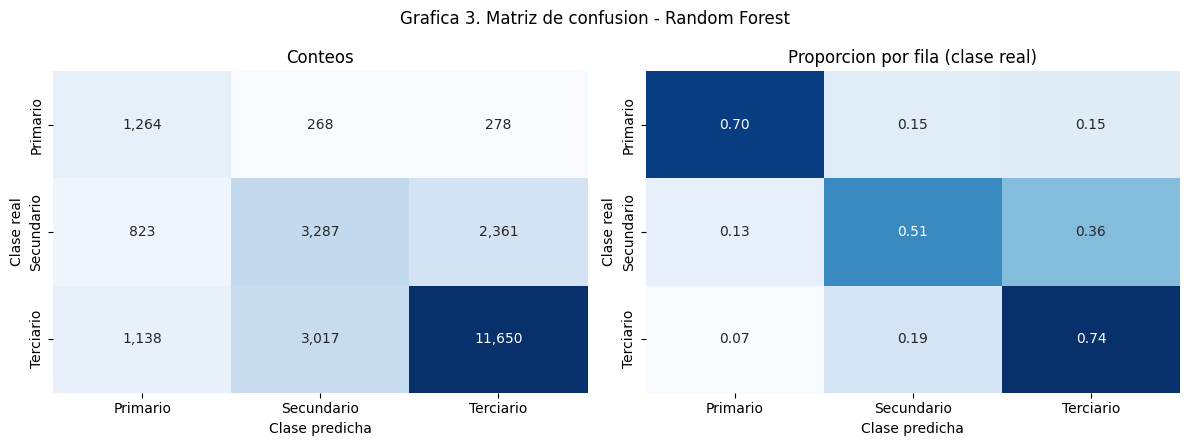

In [12]:
graficar_cm(y_test, pred_rf, 'Grafica 3. Matriz de confusion - Random Forest')

En la matriz de confusión, las filas son el sector real y las columnas el sector que predijo el modelo; la diagonal son los aciertos. En la gráfica de la derecha cada fila suma 1, así que la diagonal es la sensibilidad de cada sector:

- **Primario (70%):** de cada 10 personas que trabajan en el campo, el modelo identifica a 7.
- **Secundario (51%):** solo identifica a la mitad, y el 36% lo confunde con terciario.
- **Terciario (74%):** identifica a 3 de cada 4, y cuando falla casi siempre lo manda a secundario (19%).

La confusión más grande es entre secundario y terciario, porque son los sectores con perfiles más parecidos en escolaridad, ingreso y horas trabajadas. El primario es el más fácil de distinguir. Entonces este modelo aunque se confunde entre secundario y terciario, son casi iguales esas clases entonces comoquiera lo pondria como un modelo solido

### Importancia de variables

Para ver esta comparación de variables vamos a usar feature_importances y vamos a comparar el random forest contra el arbol individual para ver como cambian las importancias de las variables

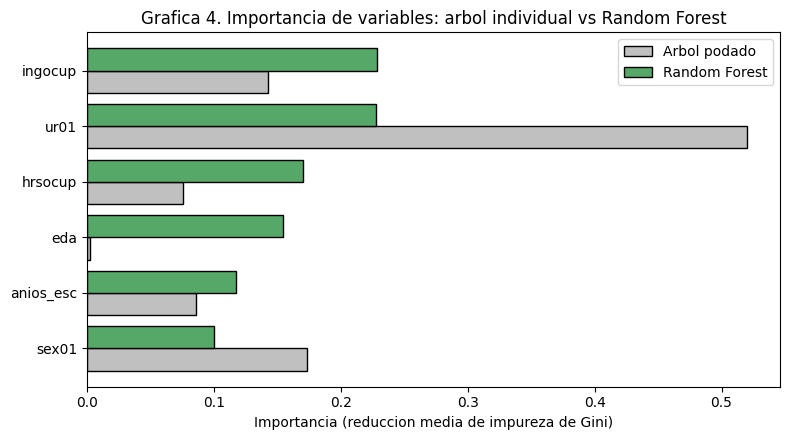

           Arbol podado  Random Forest
ingocup          0.1425         0.2289
ur01             0.5201         0.2279
hrsocup          0.0755         0.1707
eda              0.0024         0.1547
anios_esc        0.0861         0.1173
sex01            0.1734         0.1005


In [13]:
imp_rf = pd.Series(rf.feature_importances_, index=vars_arbol).sort_values()
imp_arbol = pd.Series(arbol.feature_importances_, index=vars_arbol).reindex(imp_rf.index)

fig, ax = plt.subplots(figsize=(8, 4.5))
y_pos = np.arange(len(imp_rf))
ax.barh(y_pos - 0.2, imp_arbol, height=0.4, color='#C0C0C0', edgecolor='black', label='Arbol podado')
ax.barh(y_pos + 0.2, imp_rf, height=0.4, color='#55A868', edgecolor='black', label='Random Forest')
ax.set_yticks(y_pos)
ax.set_yticklabels(imp_rf.index)
ax.set_xlabel('Importancia (reduccion media de impureza de Gini)')
ax.set_title('Grafica 4. Importancia de variables: arbol individual vs Random Forest')
ax.legend()
plt.tight_layout()
plt.show()

print(pd.DataFrame({'Arbol podado': imp_arbol, 'Random Forest': imp_rf}).sort_values('Random Forest', ascending=False).round(4))

La comparación con el árbol podado es muy reveladora:

- En el árbol podado, `ur01` (rural/urbano) tenía más de la mitad de la importancia (0.52), y `eda`(edad) prácticamente no se usaba (0.002).
- En el Random Forest la importancia está mucho más **repartida**: `ingocup`(ingreso mensual) (0.229) y `ur01` (0.228) quedan casi empatadas como las más importantes, seguidas de `hrsocup`(horas a la semana de trabajar) (0.171), `eda` (0.155), `anios_esc` (0.117) y `sex01`(Hombre/Mujer) (0.101).

Esto es justo el efecto de `max_features='sqrt'`: como en cada separación solo se pueden considerar 2 variables al azar, muchas veces `ur01` no está disponible y el árbol tiene que buscar información en otras variables. Así el modelo aprovecha información que el árbol individual ignoraba (como la edad), y eso explica parte de la mejora.

Aqui podemos ver que el random forest explora todas estas variables de una manera más uniforme, cuando el tree solo solo se enfoca en una o dos principalmente y las otras si las usa pero mucho menos

## Boosting
### Selección de hiperparametros

Se usa `GradientBoostingClassifier` de `sklearn.ensemble` con:

- `max_depth=3`: árboles pequeños (8 hojas como máximo). En boosting la idea es usar "weak learners" que aprendan poco a poco; árboles de profundidad 3 permiten capturar interacciones entre variables (por ejemplo, ingreso *y* tipo de localidad) sin ser demasiado complejos.
- `learning_rate=0.1`: cuánto aporta cada árbol nuevo. Es el valor por default y un buen equilibrio entre aprender rápido y no sobreajustar.
- `subsample=0.8`: cada árbol se entrena con un 80% de los datos elegido al azar (*stochastic gradient boosting*), lo que reduce la varianza y acelera el entrenamiento.
- `n_estimators=500` con **early stopping** (`validation_fraction=0.1` y `n_iter_no_change=10`): se aparta el 10% del entrenamiento como validación, y el modelo deja de agregar árboles cuando la pérdida en validación no mejora durante 10 iteraciones. Así el número de árboles lo decide el propio entrenamiento y no hay que adivinarlo.
- Pesos balanceados: `GradientBoostingClassifier` no tiene el parámetro `class_weight`, así que se le pasan pesos por observación (`sample_weight`) calculados con `compute_sample_weight('balanced')`, que es exactamente lo mismo.

Se eligió Gradient Boosting sobre AdaBoost porque es la versión más usada en la práctica y porque permite early stopping de forma directa.

In [14]:
from sklearn.ensemble import GradientBoostingClassifier as GBC
from sklearn.utils.class_weight import compute_sample_weight

# GradientBoosting no tiene class_weight, asi que se pasan pesos por observacion equivalentes a 'balanced'
pesos_train = compute_sample_weight('balanced', y_train)

t0 = time.time()
gb = GBC(n_estimators=500,          # maximo de arboles (el early stopping decide cuantos usar)
         learning_rate=0.1,         # tamano de paso de cada arbol
         max_depth=3,               # arboles pequenos ("weak learners")
         subsample=0.8,             # cada arbol ve 80% de los datos (stochastic gradient boosting)
         validation_fraction=0.1,   # 10% de entrenamiento se aparta para decidir cuando parar
         n_iter_no_change=10,       # paciencia: 10 arboles sin mejora -> se detiene
         random_state=67)
gb.fit(X_train_a, y_train, sample_weight=pesos_train)
t_gb = time.time() - t0

print("Arboles usados tras early stopping:", gb.n_estimators_)
pred_gb = gb.predict(X_test_a)
evaluar('Gradient Boosting', y_test, pred_gb, y_train, gb.predict(X_train_a), t_gb)

Arboles usados tras early stopping: 249
Exactitud: 0.6414
F1-score macro: 0.5734
F1-score macro en ENTRENAMIENTO: 0.5869

              precision    recall  f1-score   support

    Primario      0.326     0.796     0.463      1810
  Secundario      0.487     0.546     0.515      6471
   Terciario      0.843     0.663     0.742     15805

    accuracy                          0.641     24086
   macro avg      0.552     0.668     0.573     24086
weighted avg      0.709     0.641     0.660     24086



El early stopping paro el boosting en 249 y tuvo una exactitud de 0.6414, un F1-score macro de 0.5734 y en train 0.5869

En su f1-score saco mejor que el árbol podado (+0.031 en F1 macro), pero por debajo del Random Forest (0.5935).

La diferencia entre entrenamiento y prueba es pequeña (0.013), así que no hay un sobreajuste importante.

- Tiene la **sensibilidad macro más alta** de todos los modelos hasta ahora (0.668): detecta muy bien a primario (79.6%) y a secundario (54.6%, la más alta de todos), a cambio de detectar menos terciario (66.3%) que el Random Forest (73.7%).

Ahora vamos a ver como esta aprendiendo el modelo, entonces vamos a graficar como cambian la pérdida y el F1 conforme van agregando los arboles

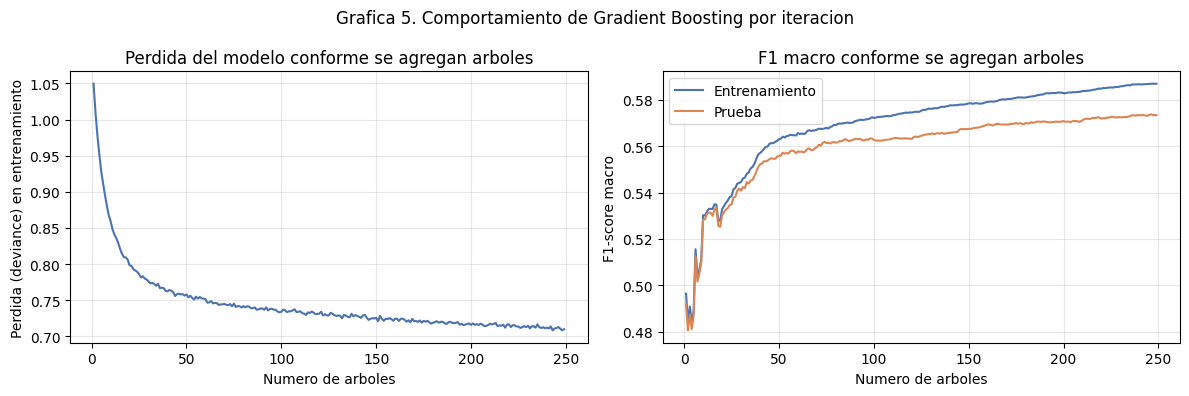

In [15]:
f1_etapas_train = [f1_score(y_train, p, average='macro') for p in gb.staged_predict(X_train_a)]
f1_etapas_test = [f1_score(y_test, p, average='macro') for p in gb.staged_predict(X_test_a)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.arange(1, gb.n_estimators_ + 1), gb.train_score_, color='#4C72B0')
axes[0].set_xlabel('Numero de arboles')
axes[0].set_ylabel('Perdida (deviance) en entrenamiento')
axes[0].set_title('Perdida del modelo conforme se agregan arboles')
axes[0].grid(alpha=0.3)

axes[1].plot(np.arange(1, gb.n_estimators_ + 1), f1_etapas_train, color='#4C72B0', label='Entrenamiento')
axes[1].plot(np.arange(1, gb.n_estimators_ + 1), f1_etapas_test, color='#DD8452', label='Prueba')
axes[1].set_xlabel('Numero de arboles')
axes[1].set_ylabel('F1-score macro')
axes[1].set_title('F1 macro conforme se agregan arboles')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.suptitle('Grafica 5. Comportamiento de Gradient Boosting por iteracion')
plt.tight_layout()
plt.show()

- En la gráfica de la izquierda la pérdida en entrenamiento baja rápido en los primeros ~50 árboles y después sigue bajando cada vez más despacio: cada árbol nuevo aporta menos.
- En la de la derecha, el F1 macro sube rápido al principio y después se aplana alrededor de 0.57. Las curvas de entrenamiento y prueba van casi juntas; la de entrenamiento se separa muy poco conforme se agregan árboles (al final la diferencia es de ~0.013), así que en este rango no hay un sobreajuste preocupante. Simplemente llega un punto en el que cada árbol nuevo aporta muy poco, y ahí es donde el early stopping corta. Si se siguieran agregando árboles, la separación entre entrenamiento y prueba crecería, así que conviene que el entrenamiento se haya detenido antes.

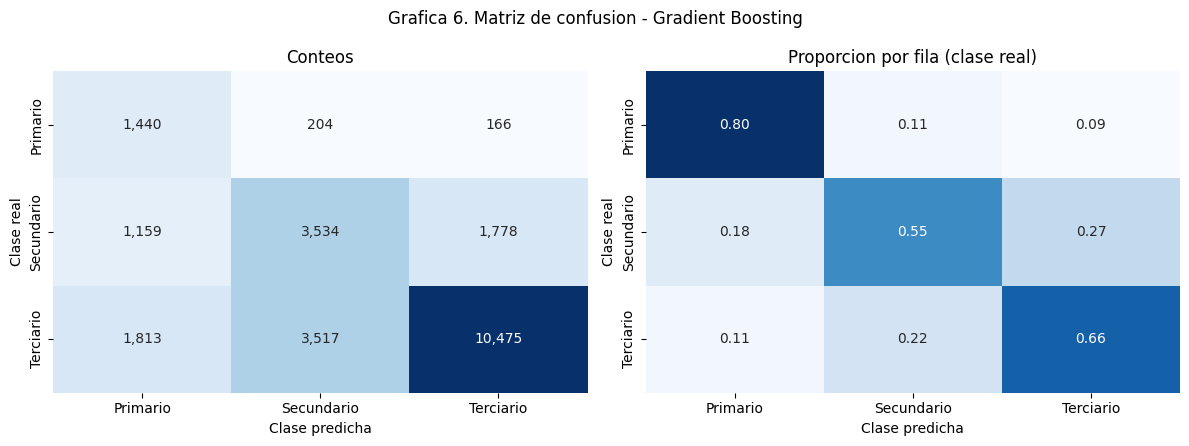

In [16]:
graficar_cm(y_test, pred_gb, 'Grafica 6. Matriz de confusion - Gradient Boosting')

La matriz de confusión confirma el patrón: primario queda muy bien detectado (80%), pero secundario y terciario se siguen confundiendo entre sí. Comparado con el Random Forest, el Boosting "manda" más casos de terciario hacia secundario (22% contra 19%) y hacia primario (11% contra 7%), por eso baja la sensibilidad de terciario y la precisión de primario (0.33).


### Importancia de variables

           Arbol podado  Random Forest  Gradient Boosting
ur01             0.5201         0.2279             0.3936
ingocup          0.1425         0.2289             0.1936
sex01            0.1734         0.1005             0.1604
hrsocup          0.0755         0.1707             0.1214
anios_esc        0.0861         0.1173             0.1112
eda              0.0024         0.1547             0.0198


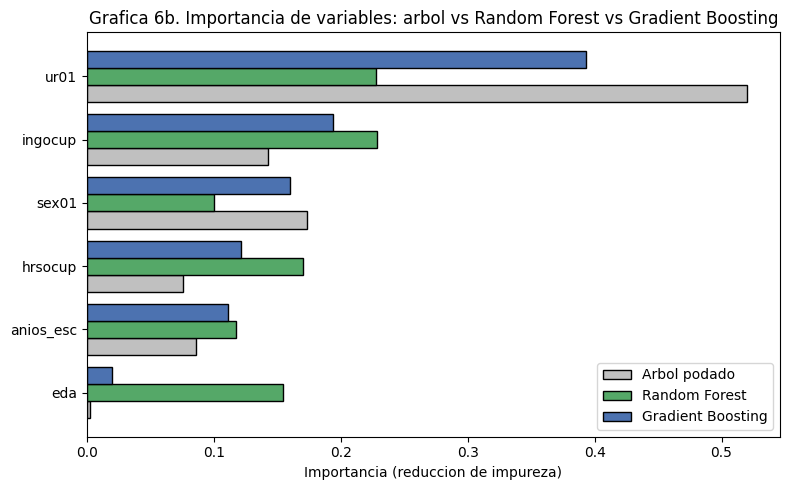

In [17]:
imp_gb = pd.Series(gb.feature_importances_, index=vars_arbol)
tabla_imp = pd.DataFrame({'Arbol podado': pd.Series(arbol.feature_importances_, index=vars_arbol),
                          'Random Forest': pd.Series(rf.feature_importances_, index=vars_arbol),
                          'Gradient Boosting': imp_gb}).sort_values('Gradient Boosting', ascending=False)
print(tabla_imp.round(4))

tabla_plot = tabla_imp.iloc[::-1]   # para que la mas importante quede arriba
fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(tabla_plot))
ax.barh(y_pos - 0.27, tabla_plot['Arbol podado'], height=0.27, color='#C0C0C0', edgecolor='black', label='Arbol podado')
ax.barh(y_pos, tabla_plot['Random Forest'], height=0.27, color='#55A868', edgecolor='black', label='Random Forest')
ax.barh(y_pos + 0.27, tabla_plot['Gradient Boosting'], height=0.27, color='#4C72B0', edgecolor='black', label='Gradient Boosting')
ax.set_yticks(y_pos)
ax.set_yticklabels(tabla_plot.index)
ax.set_xlabel('Importancia (reduccion de impureza)')
ax.set_title('Grafica 6b. Importancia de variables: arbol vs Random Forest vs Gradient Boosting')
ax.legend()
plt.tight_layout()
plt.show()

En el Gradient Boosting `ur01` vuelve a ser claramente la variable más importante (0.394), seguida de `ingocup` (0.194) y `sex01` (0.160), mientras que `eda` casi no se usa (0.020). Es un patrón más parecido al del árbol individual que al del Random Forest, lo cual tiene sentido: boosting no quita las variables disponibles en cada separación, así que cada árbol pequeño usa la variable más fuerte cuando le conviene. Los 3 modelos basados en árboles coinciden en lo principal: **vivir en una localidad rural o urbana y el ingreso son las variables que más ayudan a distinguir el sector**, lo cual es coherente con que el trabajo en el campo se concentra en zonas rurales y paga menos.

## Modelo de Support Vector Machine
### Selección de hiperparámetros

La SVM tiene un problema práctico importante: el tiempo de entrenamiento de `SVC` crece aproximadamente con el cuadrado (o más) del número de observaciones, y la predicción depende del número de vectores de soporte. Con las 96,344 observaciones de entrenamiento, entrenar (y más aún hacer validación cruzada) tomaría muchísimo tiempo. Por eso, igual que el podar arboles, se trabaja con **submuestras estratificadas del set de entrenamiento**:

1. Para elegir el kernel y $C$ se usa una submuestra de 8,000 observaciones y validación cruzada estratificada de 3 folds.
2. El modelo final se entrena con una submuestra más grande de 40,000 observaciones (el 42% del entrenamiento).

Los hiperparámetros que se prueban son:

- **Kernel:** lineal (una frontera plana, equivalente a un *support vector classifier*) contra RBF (radial, que permite fronteras no lineales).
- **$C$:** qué tanto se castigan las violaciones del margen (0.1, 1 y 10).
- `gamma='scale'` para el kernel RBF (el valor por default de sklearn, que se ajusta según la varianza de los datos).
- `class_weight='balanced'` en todos los casos, por la misma razón que en los demás modelos.

In [18]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# Submuestra pequena y estratificada del set de ENTRENAMIENTO para elegir kernel y C
X_cv, _, y_cv, _ = train_test_split(X_train_s, y_train, train_size=8000,
                                    random_state=67, stratify=y_train)

param_grid = [
    {'kernel': ['linear'], 'C': [0.1, 1]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10], 'gamma': ['scale']},
]
skf3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=67)
t0 = time.time()
busqueda = GridSearchCV(SVC(class_weight='balanced'), param_grid,
                        scoring='f1_macro', cv=skf3, n_jobs=-1)
busqueda.fit(X_cv, y_cv)
print(f"Tiempo de la busqueda: {time.time() - t0:.1f} s\n")

res_svm = pd.DataFrame(busqueda.cv_results_)[['param_kernel', 'param_C', 'mean_test_score', 'std_test_score']]
res_svm.columns = ['Kernel', 'C', 'F1 macro (CV)', 'Desv. est.']
print(res_svm.round(4).to_string(index=False))
print("\nMejor combinacion:", busqueda.best_params_)

Tiempo de la busqueda: 17.8 s

Kernel    C  F1 macro (CV)  Desv. est.
linear  0.1         0.4664      0.0052
linear  1.0         0.4664      0.0052
   rbf  0.1         0.5107      0.0038
   rbf  1.0         0.5229      0.0109
   rbf 10.0         0.5237      0.0093

Mejor combinacion: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


- El **kernel lineal** se queda en un F1 macro de 0.466 (sin importar $C$), muy parecido a la regresión logística, lo cual tiene sentido porque los dos son clasificadores lineales.
- El **kernel RBF** es claramente mejor (0.511 a 0.524), vemos que la frontera entre sectores **no es lineal**.
- Entre los valores de $C$ con kernel RBF, la diferencia entre 1 y 10 es mínima (0.523 vs 0.524, mucho menor que la desviación estándar entre folds), pero se elige $C=10$ porque es el mejor en promedio.

### Entrenamiento y evaluación

In [19]:
# Modelo final: se entrena con una submuestra estratificada mas grande (40,000 obs.)
X_svm, _, y_svm, _ = train_test_split(X_train_s, y_train, train_size=40000,
                                      random_state=67, stratify=y_train)

t0 = time.time()
svm = SVC(**busqueda.best_params_, class_weight='balanced')
svm.fit(X_svm, y_svm)
t_svm = time.time() - t0
print(f"Tiempo de entrenamiento: {t_svm:.1f} s")
print("Vectores de soporte por clase:", {c: int(n) for c, n in zip(clases, svm.n_support_)})
print(f"Proporcion de observaciones que son vectores de soporte: {svm.n_support_.sum() / len(y_svm):.2%}\n")

pred_svm = svm.predict(X_test_s)
evaluar('SVM', y_test, pred_svm, y_svm, svm.predict(X_svm), t_svm)

Tiempo de entrenamiento: 72.3 s
Vectores de soporte por clase: {'Primario': 1600, 'Secundario': 9039, 'Terciario': 19137}
Proporcion de observaciones que son vectores de soporte: 74.44%

Exactitud: 0.5969
F1-score macro: 0.5337
F1-score macro en ENTRENAMIENTO: 0.5443

              precision    recall  f1-score   support

    Primario      0.305     0.808     0.443      1810
  Secundario      0.420     0.485     0.450      6471
   Terciario      0.827     0.618     0.708     15805

    accuracy                          0.597     24086
   macro avg      0.517     0.637     0.534     24086
weighted avg      0.679     0.597     0.619     24086



- Entrenar con 40,000 observaciones tomó un minuto y medio, mucho más que cualquier otro modelo, aun usando menos de la mitad de los datos.
- **El 74.44% de las observaciones terminaron siendo vectores de soporte.** Esto es una señal de que las clases se traslapan muchísimo: la mayoría de los puntos quedan dentro del margen o del lado incorrecto, así que casi todos "participan" en definir la frontera. En un problema bien separado, solo una fracción pequeña serían vectores de soporte.
- En el set de prueba la SVM obtiene un **F1 macro de 0.534** y una exactitud de **59.7%**: prácticamente igual al árbol podado (0.542 y 59.3%), e incluso un poco peor en F1 macro. Es decir, **la SVM no logró mejorar sobre el modelo sencillo de decision tree**.
- La diferencia entre entrenamiento (0.544) y prueba (0.534) es pequeña, así que no hay sobreajuste importante; la SVM simplemente no encuentra una mejor frontera con estas variables.

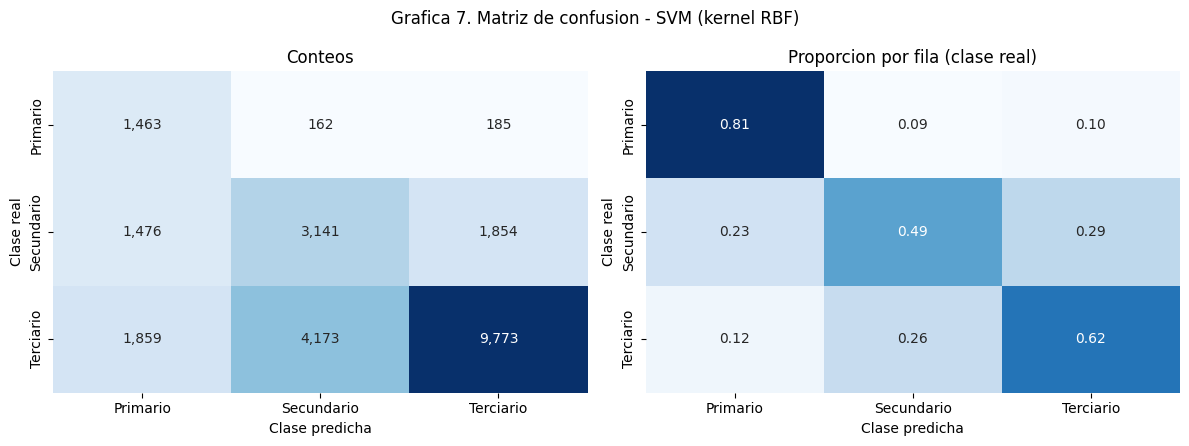

In [20]:
graficar_cm(y_test, pred_svm, 'Grafica 7. Matriz de confusion - SVM (kernel RBF)')

Igual que todas, le acierta en el sector primario, pero se equivoca en el secundario y terciario, hasta en este podemos ver que se equivoca aun más que las otras y traslapa hasta con el primario

## Modelo de red neuronal

### Selección de hiperparámetros

Se construye desde cero una red neuronal *feedforward* sencilla con `Sequential` de Keras (TensorFlow). No se necesita una capa `Flatten` porque la entrada ya es un vector de 6 variables.

- **Capa de entrada:** 6 neuronas (las 6 variables estandarizadas, con `log_ingocup`).
- **2 capas ocultas `Dense`** con 32 y 16 neuronas y activación **ReLU**. Con solo 6 variables de entrada no tiene sentido una red muy grande; una red chica ya tiene suficiente flexibilidad para capturar relaciones no lineales, y menos parámetros implica menos riesgo de sobreajuste.
- **Capa de salida:** 3 neuronas (una por sector) con activación **softmax**.
- **Optimizador Adam** con *learning rate* de **0.0005**. Es la mitad del valor por default (0.001), así que la red da pasos más pequeños en cada actualización: aprende un poco más lento, pero de forma más estable.
- **Pérdida `sparse_categorical_crossentropy`**, porque las etiquetas son enteros (0, 1, 2).
- **Batch size de 32**: los pesos se actualizan cada 32 observaciones. Con batches pequeños cada época tarda más, pero el ruido en el gradiente ayuda a regularizar el modelo.
- **Hasta 100 épocas con early stopping** (`patience=10`, `restore_best_weights=True`): si la pérdida en validación no mejora en 10 épocas, se detiene y se regresa a los pesos de la mejor época. Se deja un máximo de 100 (en vez de 50) porque, con un learning rate más bajo, la red puede necesitar más épocas para converger.
- **Validación:**: **20% del set de entrenamiento** (`validation_split=0.2`), para que el set de prueba no influya en ninguna decisión del entrenamiento.
- **Pesos por clase balanceados** (`class_weight`), igual que en el resto de los modelos.

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

tf.keras.utils.set_random_seed(67)   # para que los resultados sean reproducibles

# Keras necesita las clases como 0, 1, 2 (en vez de 1, 2, 3)
y_train_nn = y_train.values - 1
y_test_nn = y_test.values - 1

# Pesos por clase equivalentes a class_weight='balanced' de sklearn
pesos = compute_class_weight('balanced', classes=np.unique(y_train_nn), y=y_train_nn)
pesos_clase = dict(enumerate(pesos))
print("Pesos por clase:", {clases[k]: round(v, 3) for k, v in pesos_clase.items()})

red = Sequential([
    Input(shape=(len(vars_escala),)),     # capa de entrada: 6 variables escaladas
    Dense(32, activation='relu'),         # capa oculta 1
    Dense(16, activation='relu'),         # capa oculta 2
    Dense(3, activation='softmax')        # capa de salida: 1 neurona por clase
])
red.summary()

Pesos por clase: {'Primario': np.float64(4.436), 'Secundario': np.float64(1.241), 'Terciario': np.float64(0.508)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 803 (3.14 KB)

 Trainable params: 803 (3.14 KB)

 Non-trainable params: 0 (0.00 B)

La red tiene en total **803 parámetros entrenables** (224 en la primera capa oculta, 528 en la segunda y 51 en la de salida), y los pesos por clase hacen que cada error en una persona del sector primario cuente 4.4 veces, uno del secundario 1.2 veces y uno del terciario solo 0.5 veces, para compensar el desbalance. Aun siendo una red "chica", tiene bastantes más parámetros que la regresión logística, lo que le da más flexibilidad para capturar relaciones no lineales entre las variables.

### Entrenamiento

In [22]:
red.compile(optimizer=Adam(learning_rate=0.0005),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

t0 = time.time()
historial = red.fit(X_train_s.values, y_train_nn,
                    epochs=100,
                    batch_size=32,
                    validation_split=0.2,       # 20% del ENTRENAMIENTO como validacion (no se usa prueba)
                    class_weight=pesos_clase,
                    callbacks=[early_stopping],
                    verbose=1)
t_nn = time.time() - t0
print(f"Tiempo de entrenamiento: {t_nn:.1f} s")
print("Epocas ejecutadas:", len(historial.history['loss']))
print("Mejor epoca (menor val_loss):", int(np.argmin(historial.history['val_loss'])) + 1)

Epoch 1/100
2409/2409 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5732 - loss: 0.8181 - val_accuracy: 0.5969 - val_loss: 0.8334
Epoch 2/100
2409/2409 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6032 - loss: 0.7822 - val_accuracy: 0.6085 - val_loss: 0.8253
Epoch 3/100
2409/2409 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6076 - loss: 0.7763 - val_accuracy: 0.6098 - val_loss: 0.8226
Epoch 4/100
2409/2409 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6080 - loss: 0.7731 - val_accuracy: 0.6116 - val_loss: 0.8205
Epoch 5/100
2409/2409 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6078 - loss: 0.7710 - val_accuracy: 0.6106 - val_loss: 0.8196
Epoch 6/100
2409/2409 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6081 - loss: 0.7694 - val_accuracy: 0.6098 - val_loss: 0.8190
Epoch 7/100
2409/2409 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6091 - loss: 0.7683 - val_accuracy: 0.6097 - val_loss: 0.8182
Epoch 8/100
2409/2409 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6094 - loss: 0

Se tardo 5 minutos en 61 epocas, ahora vamos a graficar para ver mejor los resultados

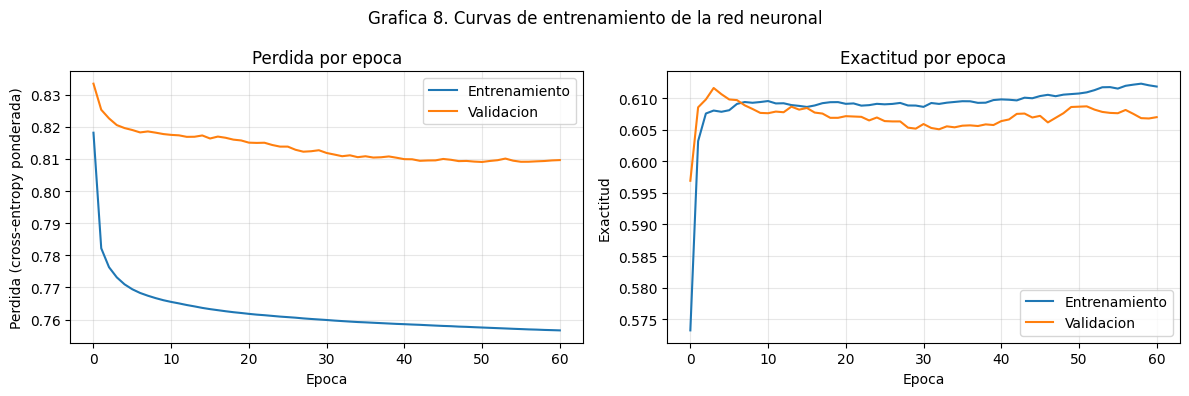

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(historial.history['loss'], label='Entrenamiento')
axes[0].plot(historial.history['val_loss'], label='Validacion')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Perdida (cross-entropy ponderada)')
axes[0].set_title('Perdida por epoca')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(historial.history['accuracy'], label='Entrenamiento')
axes[1].plot(historial.history['val_accuracy'], label='Validacion')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Exactitud')
axes[1].set_title('Exactitud por epoca')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.suptitle('Grafica 8. Curvas de entrenamiento de la red neuronal')
plt.tight_layout()
plt.show()

Podemos ver que desde la epoca 15 empezo a subir gradualmente, ambos el train y el test, pero despues del 50 empieza a tener más diferencia entre train y test y empieza a bajar

Exactitud: 0.6129
F1-score macro: 0.5495
F1-score macro en ENTRENAMIENTO: 0.5543

              precision    recall  f1-score   support

    Primario      0.322     0.777     0.455      1810
  Secundario      0.438     0.520     0.476      6471
   Terciario      0.830     0.632     0.718     15805

    accuracy                          0.613     24086
   macro avg      0.530     0.643     0.550     24086
weighted avg      0.686     0.613     0.633     24086



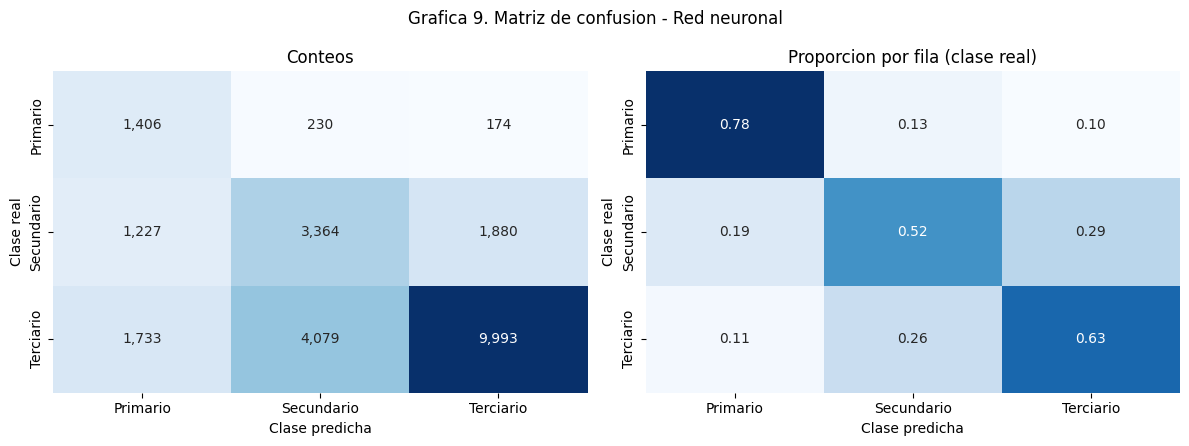

In [24]:
pred_nn = red.predict(X_test_s.values, verbose=0).argmax(axis=1) + 1       # se regresa a 1, 2, 3
pred_nn_train = red.predict(X_train_s.values, verbose=0).argmax(axis=1) + 1
evaluar('Red neuronal', y_test, pred_nn, y_train, pred_nn_train, t_nn)
graficar_cm(y_test, pred_nn, 'Grafica 9. Matriz de confusion - Red neuronal')

Podemos ver que igual que todos se enfoca y hace bien el primario y traslapa el secundario y el terceriario, aunque no se confunde tanto

Evaluación de red neuronal
- Exactitud = 0.6129
- F1-score macro=0.5495
- F1-score macro train=0.5543

podemos ver que entre train y test no hay mucha diferencia entonces no hay sobreajuste, pero a base de los demas le gana a SVM por .015 de exactitud, y .016 de F1-score, pero pierde contra boosting con .03 menos de exactitud y .024 menos en F1-score. También pierde por mucho contra el random forest con .06(0.6726) menos en exactitud y .05(0.5935) menos en F1-score.

En general este modelo solo le gana a SVM pero pierde contra boosting y random forest

# Evaluación y comparación de desempeño

Vamos a juntarlo en una tabla para ver las diferencias

In [25]:
from IPython.display import display

orden_modelos = ['Regresion logistica', 'LDA', 'Arbol de decision',
                 'Random Forest', 'Gradient Boosting', 'SVM', 'Red neuronal']
orden_modelos = [m for m in orden_modelos if m in resultados]   # la red solo aparece si ya se corrio

tabla = pd.DataFrame(resultados).T.loc[orden_modelos].astype(float)

metricas_tabla = ['Exactitud', 'Precision (macro)', 'Sensibilidad (macro)', 'F1-score (macro)']
tabla_bonita = (tabla.style
    .format({m: '{:.3f}' for m in metricas_tabla} | {'Tiempo de entrenamiento (s)': '{:.1f} s'})
    .highlight_max(subset=metricas_tabla, props='background-color: #C6EFCE; font-weight: bold')
    .highlight_min(subset=['Tiempo de entrenamiento (s)'], props='background-color: #C6EFCE; font-weight: bold')
    .background_gradient(subset=['F1-score (macro)'], cmap='Blues')
    .set_caption('Tabla 1. Metricas de cada modelo en el conjunto de prueba')
    .set_table_styles([
        {'selector': 'caption', 'props': 'font-size: 14px; font-weight: bold; padding-bottom: 8px;'},
        {'selector': 'th', 'props': 'text-align: center; background-color: #4C72B0; color: white; padding: 6px 10px;'},
        {'selector': 'td', 'props': 'text-align: center; padding: 6px 10px;'},
    ]))
display(tabla_bonita)

,Exactitud,Precision (macro),Sensibilidad (macro),F1-score (macro),Tiempo de entrenamiento (s)
Regresion logistica,0.552,0.482,0.608,0.488,0.2 s
LDA,0.493,0.447,0.521,0.434,0.1 s
Arbol de decision,0.593,0.523,0.637,0.542,4.8 s
Random Forest,0.673,0.569,0.648,0.593,17.9 s
Gradient Boosting,0.641,0.552,0.668,0.573,35.3 s
SVM,0.597,0.517,0.637,0.534,72.3 s
Red neuronal,0.613,0.530,0.643,0.550,276.3 s


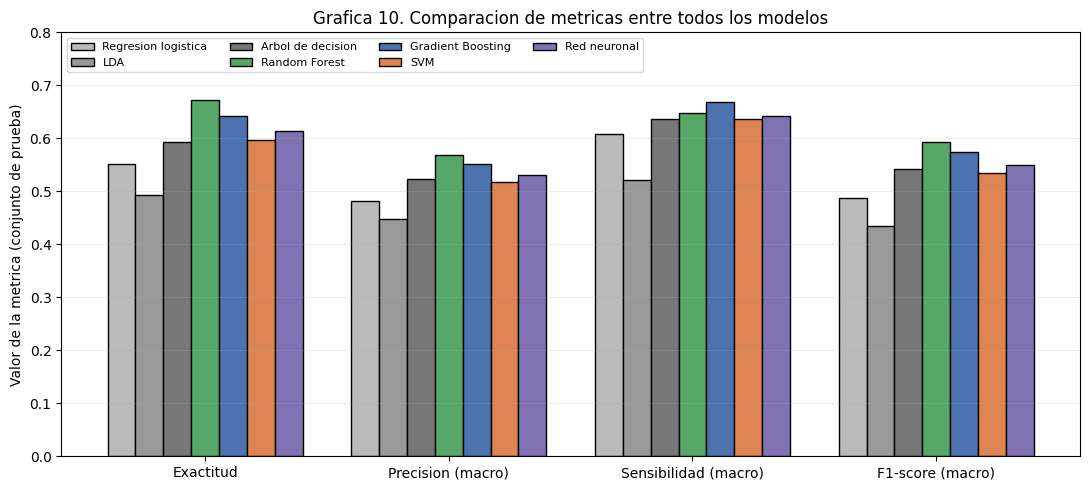

In [26]:
metricas = ['Exactitud', 'Precision (macro)', 'Sensibilidad (macro)', 'F1-score (macro)']
colores_m = {'Regresion logistica': '#BBBBBB', 'LDA': '#999999', 'Arbol de decision': '#777777',
             'Random Forest': '#55A868', 'Gradient Boosting': '#4C72B0', 'SVM': '#DD8452',
             'Red neuronal': '#8172B3'}

fig, ax = plt.subplots(figsize=(11, 5))
ancho = 0.8 / len(orden_modelos)
x = np.arange(len(metricas))
for i, m in enumerate(orden_modelos):
    vals = tabla.loc[m, metricas].astype(float).values
    ax.bar(x + i * ancho - 0.4 + ancho / 2, vals, width=ancho, label=m,
           color=colores_m[m], edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 0.8)
ax.set_ylabel('Valor de la metrica (conjunto de prueba)')
ax.set_title('Grafica 10. Comparacion de metricas entre todos los modelos')
ax.legend(ncol=4, fontsize=8, loc='upper left')
ax.grid(alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

**Qué modelo tuvo mejor desempeño:**

- El **Random Forest** es el mejor en F1 macro (0.594), exactitud (67.3%) y precisión macro (0.569).
- El **Gradient Boosting** queda en segundo lugar en F1 macro (0.573) y es el mejor en sensibilidad macro (0.668).
- La **Red neuronal:** queda en tercer lugar con un F1-score macro de 0.5495 y una exactitud de 0.6129
- La **SVM** (0.534) queda prácticamente empatada con el árbol podado (0.542).
- Los modelos lineales (regresión logística 0.488 y LDA 0.434) quedan claramente abajo.

Veamos el detalle por clase, porque el F1 macro esconde que cada modelo tiene un "estilo" distinto de equivocarse.

In [28]:
# Sensibilidad (recall) por clase de cada modelo: que tan bien detecta cada sector
preds = {'Regresion logistica': logreg.predict(X_test_s),
         'LDA': lda.predict(X_test_s[vars_lda]),
         'Arbol de decision': arbol.predict(X_test_a),
         'Random Forest': pred_rf, 'Gradient Boosting': pred_gb, 'SVM': pred_svm}
if 'pred_nn' in globals():
    preds['Red neuronal'] = pred_nn

recall_clase = pd.DataFrame({m: recall_score(y_test, p, average=None) for m, p in preds.items()},
                            index=['Recall ' + c for c in clases]).T
precision_clase = pd.DataFrame({m: precision_score(y_test, p, average=None) for m, p in preds.items()},
                               index=['Precision ' + c for c in clases]).T
print(pd.concat([recall_clase, precision_clase], axis=1).round(3).to_string())

                     Recall Primario  Recall Secundario  Recall Terciario  Precision Primario  Precision Secundario  Precision Terciario
Regresion logistica            0.839              0.403             0.581               0.261                 0.377                0.808
LDA                            0.577              0.508             0.477               0.178                 0.387                0.777
Arbol de decision              0.780              0.538             0.595               0.337                 0.412                0.821
Random Forest                  0.698              0.508             0.737               0.392                 0.500                0.815
Gradient Boosting              0.796              0.546             0.663               0.326                 0.487                0.843
SVM                            0.808              0.485             0.618               0.305                 0.420                0.827
Red neuronal                   0.777     

- **Primario:** todos los modelos no lineales lo detectan bien (sensibilidad entre 70% y 81%), pero su precisión es baja en todos (0.31–0.39). El Random Forest es el que tiene mejor precisión en primario (0.392) aunque detecta un poco menos (69.8%).
- **Secundario** es la clase más difícil en todos los modelos: ninguno pasa de 55% de sensibilidad ni de 0.50 de precisión. El Gradient Boosting es el que mejor lo detecta (54.6%) y el Random Forest el más preciso (0.500).
- **Terciario:** el Random Forest es, por mucho, el que mejor lo detecta (73.7%), mientras que los demás se quedan entre 58% y 66%. Esto explica buena parte de su ventaja en exactitud, porque terciario es la clase más grande.

## ¿Las diferencias son sustanciales o marginales?

Para responder esto no basta con ver un solo número en el set de prueba: hay que saber cuánto **varía** el desempeño de cada modelo si cambian un poco los datos. Para eso se hace una validación cruzada estratificada de 5 folds (sobre una submuestra de 20,000 observaciones de **entrenamiento**, con los mismos hiperparámetros elegidos antes). Si la diferencia entre dos modelos es mucho más grande que la variación entre folds, la diferencia es real; si es del mismo tamaño, es marginal.

In [29]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

# Estabilidad: validacion cruzada estratificada de 5 folds sobre una submuestra de 20,000 obs. de ENTRENAMIENTO
idx_cv, _ = train_test_split(train.index, train_size=20000, random_state=67, stratify=y_train)
Xa_cv, Xs_cv, y_cv5 = X_train_a.loc[idx_cv], X_train_s.loc[idx_cv], y_train.loc[idx_cv]
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=67)

modelos_cv = {
    'Regresion logistica': (LogisticRegression(class_weight='balanced', max_iter=1000), Xs_cv),
    'LDA': (LDA(priors=[1/3, 1/3, 1/3]), Xs_cv[vars_lda]),
    'Arbol de decision': (DTC(random_state=67, class_weight='balanced', ccp_alpha=0.00041576), Xa_cv),
    'Random Forest': (RFC(n_estimators=300, max_features='sqrt', min_samples_leaf=msl_opt,
                          class_weight='balanced', n_jobs=-1, random_state=67), Xa_cv),
    'SVM': (SVC(**busqueda.best_params_, class_weight='balanced'), Xs_cv),
}

cv_res = {}
for nombre, (modelo, Xcv) in modelos_cv.items():
    s = cross_val_score(modelo, Xcv, y_cv5, cv=skf5, scoring='f1_macro', n_jobs=-1)
    cv_res[nombre] = s

# Gradient Boosting necesita los pesos balanceados en cada fold, asi que se hace el ciclo a mano
s_gb = []
for tr_i, va_i in skf5.split(Xa_cv, y_cv5):
    m = GBC(n_estimators=500, learning_rate=0.1, max_depth=3, subsample=0.8,
            validation_fraction=0.1, n_iter_no_change=10, random_state=67)
    m.fit(Xa_cv.iloc[tr_i], y_cv5.iloc[tr_i],
          sample_weight=compute_sample_weight('balanced', y_cv5.iloc[tr_i]))
    s_gb.append(f1_score(y_cv5.iloc[va_i], m.predict(Xa_cv.iloc[va_i]), average='macro'))
cv_res['Gradient Boosting'] = np.array(s_gb)

In [30]:
s_nn = []
for tr_i, va_i in skf5.split(Xs_cv, y_cv5):
    tf.keras.utils.set_random_seed(67)
    m = Sequential([Input(shape=(len(vars_escala),)), Dense(32, activation='relu'),
                    Dense(16, activation='relu'), Dense(3, activation='softmax')])
    m.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    y_tr_f = y_cv5.iloc[tr_i].values - 1
    pesos_f = dict(enumerate(compute_class_weight('balanced', classes=np.unique(y_tr_f), y=y_tr_f)))
    m.fit(Xs_cv.iloc[tr_i].values, y_tr_f, epochs=100, batch_size=256, validation_split=0.2,
          class_weight=pesos_f, verbose=0,
          callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)])
    p = m.predict(Xs_cv.iloc[va_i].values, verbose=0).argmax(axis=1) + 1
    s_nn.append(f1_score(y_cv5.iloc[va_i], p, average='macro'))
cv_res['Red neuronal'] = np.array(s_nn)
print(f"Red neuronal - F1 macro CV: {np.mean(s_nn):.4f} +/- {np.std(s_nn):.4f}")

Red neuronal - F1 macro CV: 0.5307 +/- 0.0099


In [31]:
orden_cv = [m for m in orden_modelos if m in cv_res]
tabla_cv = pd.DataFrame({'F1 macro CV (promedio)': {m: cv_res[m].mean() for m in orden_cv},
                         'Desv. est.': {m: cv_res[m].std() for m in orden_cv},
                         'Minimo': {m: cv_res[m].min() for m in orden_cv},
                         'Maximo': {m: cv_res[m].max() for m in orden_cv}}).loc[orden_cv]
print(tabla_cv.round(4).to_string())

                     F1 macro CV (promedio)  Desv. est.  Minimo  Maximo
Regresion logistica                  0.4840      0.0085  0.4743  0.4976
LDA                                  0.4325      0.0055  0.4257  0.4412
Arbol de decision                    0.5309      0.0111  0.5156  0.5489
Random Forest                        0.5880      0.0052  0.5817  0.5964
Gradient Boosting                    0.5662      0.0064  0.5595  0.5763
SVM                                  0.5233      0.0055  0.5168  0.5315
Red neuronal                         0.5307      0.0099  0.5217  0.5430


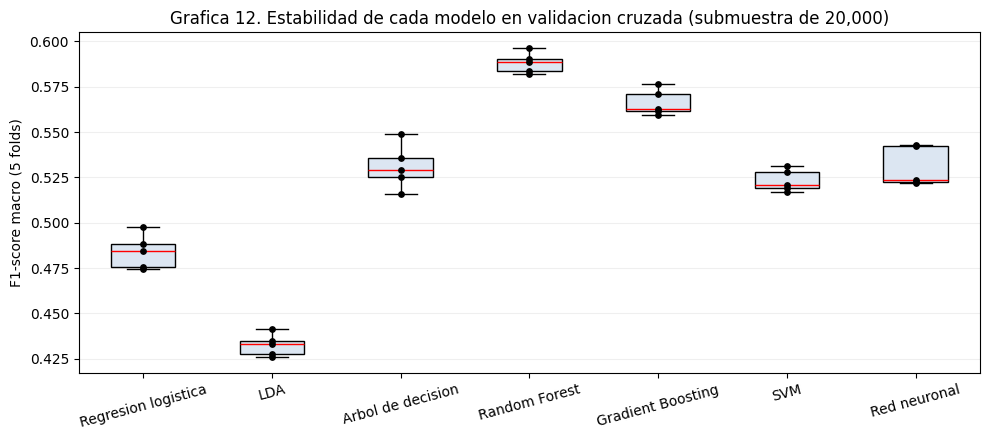

In [32]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.boxplot([cv_res[m] for m in orden_cv], labels=orden_cv, patch_artist=True,
           boxprops=dict(facecolor='#DCE6F2'), medianprops=dict(color='red'))
for i, m in enumerate(orden_cv, start=1):
    ax.scatter(np.full(5, i), cv_res[m], color='black', s=15, zorder=3)
ax.set_ylabel('F1-score macro (5 folds)')
ax.set_title('Grafica 12. Estabilidad de cada modelo en validacion cruzada (submuestra de 20,000)')
plt.xticks(rotation=15)
ax.grid(alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

- La desviación estándar entre folds es pequeña en todos los modelos (entre 0.005 y 0.011), así que los resultados son **estables**.
- **Random Forest vs árbol podado:** 0.588 contra 0.531 en validación cruzada (0.594 vs 0.542 en prueba). La diferencia (~0.05) es unas 5 veces la desviación estándar, así que **la mejora es sustancial y consistente**. Además, el peor fold del Random Forest (0.582) está por encima del mejor fold del árbol (0.549). El Random Forest también es el modelo **más estable** de todos (desviación estándar de 0.005 contra 0.011 del árbol), lo cual es justo lo que se espera del bagging: reducir la varianza de los árboles.
- **Gradient Boosting vs árbol podado:** 0.566 contra 0.531, también una mejora clara (unas 3–5 desviaciones estándar).
- **Random Forest vs Gradient Boosting:** 0.588 contra 0.566. La diferencia (0.02) es pequeña pero consistente: el peor fold del Random Forest (0.582) es mejor que el **mejor** fold del Boosting (0.576), así que en ningún caso el Boosting lo alcanza. Es una ventaja real pero **moderada**.
- **SVM vs árbol podado:** 0.523 contra 0.531, prácticamente igual (la diferencia está dentro de la variación entre folds). **La SVM no aporta una mejora real.**
- **Red neuronal vs árbol podado:** 0.531 contra 0.531, **exactamente el mismo promedio**. La red no mejora al árbol sencillo, y además es de los modelos **menos estables** (desviación estándar de 0.010, solo por debajo del árbol), con folds que van de 0.522 a 0.543. Esto tiene sentido porque el resultado de una red depende de la inicialización aleatoria de sus pesos y de en qué época se detiene el early stopping. Así que, igual que la SVM, **la red neuronal no aporta una mejora real** en este problema, a pesar de ser mucho más compleja que el árbol.

## Complejidad del modelo vs mejora en desempeño

Para ver la relación entre complejidad y mejora hay que considerar también el tiempo de entrenamiento y el sobreajuste. Primero, la comparación entre entrenamiento y prueba:

                     F1 macro entrenamiento  F1 macro prueba  Diferencia
Regresion logistica                  0.4901           0.4879      0.0023
LDA                                  0.4365           0.4340      0.0025
Arbol de decision                    0.5459           0.5424      0.0035
Random Forest                        0.7195           0.5935      0.1260
Gradient Boosting                    0.5869           0.5734      0.0135
SVM                                  0.5443           0.5337      0.0107
Red neuronal                         0.5543           0.5495      0.0048


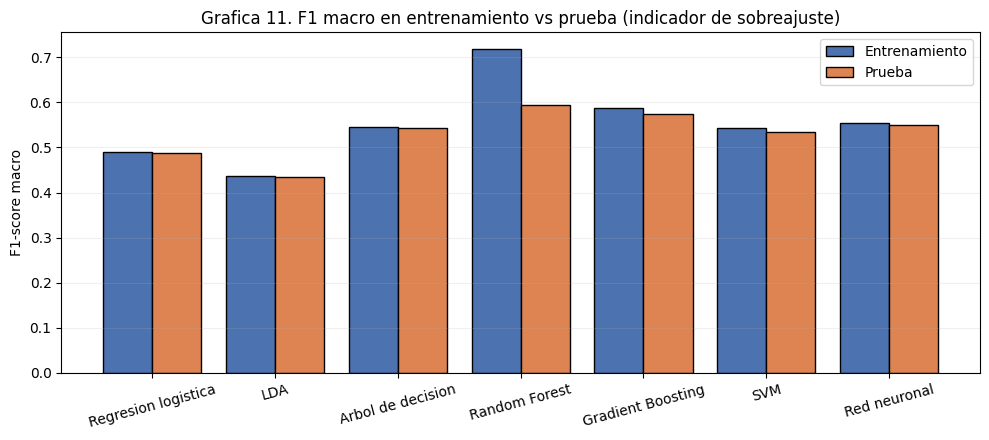

In [33]:
tabla_brecha = pd.DataFrame(brecha).T.loc[orden_modelos]
print(tabla_brecha.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(tabla_brecha))
ax.bar(x - 0.2, tabla_brecha['F1 macro entrenamiento'], width=0.4, color='#4C72B0', edgecolor='black', label='Entrenamiento')
ax.bar(x + 0.2, tabla_brecha['F1 macro prueba'], width=0.4, color='#DD8452', edgecolor='black', label='Prueba')
ax.set_xticks(x)
ax.set_xticklabels(tabla_brecha.index, rotation=15)
ax.set_ylabel('F1-score macro')
ax.set_title('Grafica 11. F1 macro en entrenamiento vs prueba (indicador de sobreajuste)')
ax.legend()
ax.grid(alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

Juntando todo:

| Modelo | Complejidad | F1 macro prueba | Mejora vs árbol | Tiempo aprox. de entrenamiento | Brecha train–test |
|---|---|---|---|---|---|
| Regresión logística | Baja (lineal) | 0.488 | −0.054 | < 1 s | 0.002 |
| LDA | Baja (lineal) | 0.434 | −0.108 | < 1 s | 0.003 |
| Árbol podado | Baja–media (39 hojas) | 0.542 | — | ~5 s | 0.004 |
| Random Forest | Alta (300 árboles profundos) | **0.594** | **+0.051** | ~13 s | 0.126 |
| Gradient Boosting | Alta (249 árboles secuenciales) | 0.573 | +0.031 | ~35 s | 0.013 |
| SVM (RBF) | Alta (~30,000 vectores de soporte) | 0.534 | −0.009 | ~70 s (con solo 40% de los datos) | 0.011 |
| Red neuronal | Alta (803 parámetros, 2 capas ocultas) | 0.550 | +0.007 | Varios minutos (batch de 32) | 0.005 |

(Los tiempos pueden variar dependiendo de la computadora; lo importante es la diferencia relativa entre modelos.)

**Relación entre complejidad y desempeño:**

- El salto más grande en desempeño se dio al pasar de modelos **lineales** a modelos **no lineales** (de ~0.49 de la logística a ~0.54 del árbol): la frontera entre sectores simplemente no es lineal.
- Pasar de **un árbol a muchos árboles** (Random Forest y Boosting) dio otra mejora clara, aunque más chica (+0.03 a +0.05).
- Pero **más complejidad no siempre significa mejor desempeño**: la SVM, que es el modelo más costoso computacionalmente, no mejoró nada sobre el árbol. Su complejidad está en un lugar (fronteras suaves en un espacio de dimensión infinita) que no le ayuda a este problema, donde las variables binarias y los cortes por umbral (como los que hacen los árboles) parecen capturar mejor la estructura de los datos.
- Algo parecido pasa con la **red neuronal**: en prueba sale apenas un poco mejor que el árbol (0.550 contra 0.542), pero en validación cruzada quedaron exactamente iguales (0.531 ambos), así que esa diferencia de +0.007 es **marginal** y cae dentro de la variación normal entre particiones. Casi no sobreajusta (brecha de 0.005, gracias al early stopping), pero tardó mucho más en entrenar que el árbol y fue de los modelos menos estables entre folds. Con solo 6 variables tabulares, su flexibilidad extra no se traduce en una mejora real.
- Las mejoras son **moderadas** en términos absolutos: ni el mejor modelo pasa de 0.60 de F1 macro. Esto indica que el límite no está tanto en el modelo sino en la **información disponible**: con solo 6 variables sociodemográficas, secundario y terciario se parecen demasiado (misma escolaridad, ingreso y horas parecidas) y ningún modelo, por complejo que sea, puede separarlos bien.

# Análisis Crítico y Conclusiones

El objetivo de este reporte era ver si modelos más complejos (Random Forest, Gradient Boosting, SVM y una red neuronal) predicen mejor el sector económico de una persona que los modelos sencillos de referencia (LDA y árbol de decisión), y si esa mejora vale la pena.

### ¿El aumento en complejidad se tradujo en mejoras claras?

Solo en los métodos de ensamble. El **Random Forest** (F1 macro de 0.594) y el **Gradient Boosting** (0.573) sí mejoraron de forma clara sobre el árbol podado (0.542), y la validación cruzada confirma que esa mejora es real y no suerte de la partición. En cambio, la **SVM** (0.534) y la **red neuronal** (0.550) no mejoraron de verdad: la SVM quedó abajo del árbol, y la red en prueba le gana por solo 0.007, pero en validación cruzada quedaron exactamente iguales (0.531 los dos), entonces esa diferencia es puro ruido.

Entonces más complejidad no significa mejor modelo. Lo que funcionó no fue tener fronteras más "suaves" (SVM) o más parámetros (red neuronal), sino **juntar muchos árboles para reducir la varianza**. Con solo 6 variables, y la mayoría de la información en variables binarias (rural/urbano y sexo) y en cortes de ingreso y escolaridad, los modelos basados en árboles son los que mejor le entienden a estos datos.

### Riesgos de sobreajuste

- El **Random Forest** es el único con una brecha grande entre entrenamiento (0.720) y prueba (0.594). Pero esto no le afecta en datos nuevos: el OOB, la validación cruzada y la prueba dan prácticamente lo mismo (~0.59). Cada árbol sí memoriza parte de sus datos, pero al promediar 300 árboles esos errores se cancelan. Lo que sí hay que tener claro es que el desempeño en entrenamiento de un Random Forest no sirve para evaluarlo.
- El **Gradient Boosting** (0.013) y la **red neuronal** (0.005) casi no sobreajustan, y en los dos es gracias al early stopping, que cortó el entrenamiento antes de que se empezaran a separar entrenamiento y validación.
- La **SVM** tampoco tiene sobreajusto (0.011), pero que el 74% de las observaciones sean vectores de soporte nos dice que las clases se traslapan muchísimo y que el modelo depende de casi todos los puntos, lo que lo hace lento y pesado.

### Interpretabilidad

De más a menos interpretable:

1. **Árbol podado:** se puede leer regla por regla, pero es el que peor predice de los modelos no lineales.
2. **Random Forest y Gradient Boosting:** no se pueden leer los cientos de árboles, pero sí dan importancia de variables, y con eso se vio que el tipo de localidad y el ingreso son lo que más ayuda a distinguir el sector.
3. **SVM y red neuronal:** son cajas negras, no dan ninguna medida directa de qué variables usan. Y encima no predijeron mejor, entonces pierden en los dos lados.

### ¿Cuándo usar cada uno?

- **Random Forest:** es el que yo usaría para este problema. Tiene el mejor F1 macro y la mejor exactitud, es el más estable en validación cruzada, entrena en segundos y da importancia de variables.
- **Gradient Boosting:** lo usaría si lo más importante fuera no dejar fuera a las personas del campo o de la industria (por ejemplo, para un programa de apoyo), porque tiene la sensibilidad más alta en primario y secundario. Pero es más lento y en general queda abajo del Random Forest.
- **SVM:** no la usaría aquí. Es la más lenta (y eso que solo se entrenó con 40,000 observaciones) y no le gana ni al árbol. Tendría más sentido en problemas con menos observaciones y más variables continuas.
- **Red neuronal:** tampoco la usaría aquí. Tardó 5 minutos en 61 épocas, no se puede interpretar y queda igual que un árbol que entrena en segundos. Una red neuronal tiene sentido con muchos datos y patrones complejos, como imágenes (MNIST), no con 6 variables tabulares.
- **Árbol de decisión:** si tuviera que explicarle el modelo a alguien no técnico, aunque pierda un poco de desempeño.

### Conclusión

El **Random Forest es el mejor modelo** para predecir el sector económico con estos datos: F1 macro de 0.594 y exactitud de 67.3%, le gana a todos y es el más estable. El Gradient Boosting queda en segundo lugar, y la SVM y la red neuronal no justifican su complejidad porque no mejoran al árbol sencillo.

Aun así, ningún modelo pasa de 0.60 de F1 macro, y todos se equivocan en lo mismo: confunden secundario con terciario. Esto me dice que el límite no está en el modelo sino en las variables: con edad, escolaridad, ingreso, horas, sexo y tipo de localidad se identifica muy bien al sector primario (rural, hombres, menor ingreso), pero la industria y los servicios tienen perfiles de trabajadores demasiado parecidos. Para mejorar de verdad no hace falta un modelo más complejo, sino agregar información como la entidad federativa o el tipo de ocupación.

# Referencias

- INEGI (2026). *Encuesta Nacional de Ocupación y Empleo (ENOE), primer trimestre de 2026*. Microdatos. Instituto Nacional de Estadística y Geografía. https://www.inegi.org.mx/programas/enoe/15ymas/
- INEGI. *Encuesta Nacional de Ocupación y Empleo. Diccionario de datos, SDEMT225*. https://www.inegi.org.mx/rnm/index.php/catalog/1121/data-dictionary/F42?file_name=SDEMT225
- James, G., Witten, D., Hastie, T. y Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2a ed.). Springer. Capítulos 8 (métodos basados en árboles), 9 (Support Vector Machines) y 10 (Deep Learning).
- Nielsen, M. (2015). *Neural Networks and Deep Learning*. http://neuralnetworksanddeeplearning.com
- Documentación de scikit-learn: `RandomForestClassifier`, `GradientBoostingClassifier`, `SVC`. https://scikit-learn.org/stable/
- Documentación de TensorFlow/Keras. https://www.tensorflow.org/api_docs/python/tf/keras